In [2]:
import pandas as pd

df = pd.read_csv("../data_clean/df_model_prepared.csv")

df_clean = df.drop_duplicates(subset=["municipality_code"])

df_clean.to_csv("../data_clean/df_model_prepared.csv", index=False)


In [3]:
df_geo = pd.read_csv("../data_clean/df_geo.csv")

df_geo_2023 = df_geo[df_geo["year"] == 2023].drop_duplicates(subset=["municipality_code"])

df_geo_2023.to_csv("../data_clean/df_geo_2023.csv", index=False)


In [4]:
import pandas as pd

X = pd.read_csv('../data_clean/X_features.csv')
y = pd.read_csv('../data_clean/y_target.csv')

print(len(X), len(y))
print(X["municipality_code"].nunique())
print(y["municipality_code"].nunique())


1690 1690


KeyError: 'municipality_code'

In [5]:
df = pd.read_csv("../data_clean/df_analysis_base.csv")
print(df.columns)
print()

df_model_prepared = pd.read_csv("../data_clean/df_model_prepared.csv")
print(df_model_prepared.columns)
print()

df_geo = pd.read_csv("../data_clean/df_geo_2023.csv")
print(df.columns)
print()

Index(['municipality_code', 'year', 'price_total', 'price_egw', 'price_mgw',
       'ratio_price_model', 'ratio_price_realized', 'share_egw', 'share_mgw',
       'housing_stock_egw_x', 'housing_stock_mgw_x', 'ratio_area',
       'ratio_stock', 'gemeentenaam', 'population', 'bevolkingsdichtheid',
       'households', 'woningvoorraad_total', 'housing_stock_egw_y',
       'housing_stock_mgw_y', 'living_space_total', 'living_space_egw',
       'living_space_mgw', 'income_mean', 'income_median', 'woz_mean',
       'pipeline_total', 'pipeline_started', 'pipeline_permit',
       'new_build_stock_tot', 'new_build_liv_space_tot', 'new_build_stock_egw',
       'new_build_liv_space_egw', 'new_build_stock_mgw',
       'new_build_liv_space_mgw', 'unemployment_rate',
       'labor_participation_gross', 'labor_participation_net',
       'employment_rate', 'population_jan1', 'population_dec31',
       'migration_net', 'migration_per_1000', 'migration_rate',
       'avg_space_egw', 'avg_space_mgw', 'ra

In [6]:
print("Anzahl Gemeinden:", df.shape[0])
print("NA in price_total:", df["price_total"].isna().sum())
print("NA in woz_mean:", df["woz_mean"].isna().sum())
print("Anzahl price_total == 0:", (df["price_total"] == 0).sum())
print("Anzahl woz_mean == 0:", (df["woz_mean"] == 0).sum())


Anzahl Gemeinden: 341
NA in price_total: 0
NA in woz_mean: 0
Anzahl price_total == 0: 0
Anzahl woz_mean == 0: 0


In [8]:
import numpy as np

df["log_price_total"] = np.log(df["price_total"])
df["log_woz_mean"] = np.log(df["woz_mean"])

print("NA in log_price_total:", df["log_price_total"].isna().sum())
print("NA in log_woz_mean:", df["log_woz_mean"].isna().sum())


NA in log_price_total: 0
NA in log_woz_mean: 185


C:\Users\sk\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [9]:
print(df["log_price_total"].describe())
print(df["log_woz_mean"].describe())


count    341.000000
mean      12.917866
std        0.213477
min       12.281903
25%       12.793429
50%       12.909841
75%       13.030316
max       13.900600
Name: log_price_total, dtype: float64
count    156.000000
mean      -0.905954
std        1.433754
min       -6.947137
25%       -1.479894
50%       -0.643636
75%        0.025023
max        1.797256
Name: log_woz_mean, dtype: float64


In [12]:
df_woz = pd.read_csv("../data_clean/df_woz_clean.csv")

# Falls year als String eingelesen wurde:
df_woz["year"] = pd.to_numeric(df_woz["year"], errors="coerce")

# Filter auf 2023
df_woz_2023 = df_woz[df_woz["year"] == 2023]

print("Shape:", df_woz_2023.shape)
print(df_woz_2023.describe(include="all"))


Shape: (360, 3)
       municipality_code    year       woz_mean
count                360   360.0     342.000000
unique               360     NaN            NaN
top               GM1680     NaN            NaN
freq                   1     NaN            NaN
mean                 NaN  2023.0  374005.847953
std                  NaN     0.0   93719.397559
min                  NaN  2023.0  195000.000000
25%                  NaN  2023.0  313250.000000
50%                  NaN  2023.0  363000.000000
75%                  NaN  2023.0  415750.000000
max                  NaN  2023.0  925000.000000


In [13]:
df_residual = pd.read_csv("../data_clean/df_residual_2023.csv")
print("df_residual:", df_residual.shape)
df_residual.head()

df_residual: (341, 17)


,municipality_code,gemeentenaam,woz_mean,log_woz_mean,price_total,log_price_total,residual_woz,is_randstad,income_mean,bevolkingsdichtheid,share_egw,avg_space_egw,migration_rate,woningvoorraad_total,pipeline_total,employment_rate,ratio_price_model
0,GM0014,Groningen (gemeente),294000.0,12.591335,349931.0,12.765491,0.038320,0,-1.466662,1284.0,0.390099,0.990298,2.360307,2.611084,1.303138,-3.652659,-1.411029
1,GM0034,Almere,363000.0,12.802158,424531.0,12.958740,0.041246,1,-0.281377,1725.0,0.709317,0.990195,1.649276,1.779708,1.699302,-2.134481,-0.792854
2,GM0037,Stadskanaal,242000.0,12.396693,265130.0,12.487976,-0.063481,0,-0.983768,273.0,0.785333,0.999916,-0.379648,-0.231567,-0.280865,-0.616303,-0.371113
3,GM0047,Veendam,212000.0,12.264342,269888.0,12.505762,0.073788,0,-0.910602,364.0,0.786214,0.995233,-0.347625,-0.285897,-0.198358,-1.050068,-0.254595
4,GM0050,Zeewolde,393000.0,12.881565,390515.0,12.875222,-0.113958,1,-0.061880,96.0,0.837930,0.984055,0.873713,-0.373843,-0.229134,0.251228,0.186645


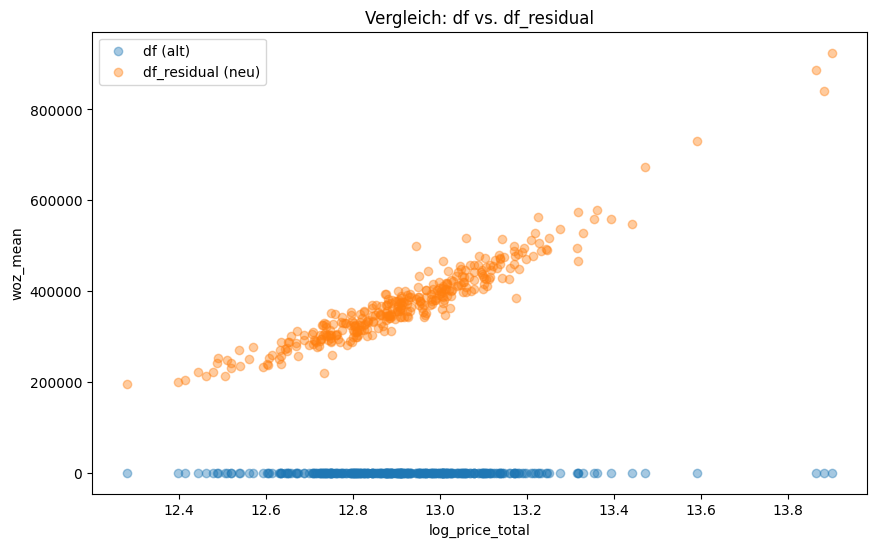

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

# Bisheriges df
plt.scatter(
    df["log_price_total"],
    df["woz_mean"],
    alpha=0.4,
    label="df (alt)"
)

# Neues df_residual
plt.scatter(
    df_residual["log_price_total"],
    df_residual["woz_mean"],
    alpha=0.4,
    label="df_residual (neu)"
)

plt.xlabel("log_price_total")
plt.ylabel("woz_mean")
plt.title("Vergleich: df vs. df_residual")
plt.legend()
plt.show()


In [15]:
df.columns
df_residual.columns


Index(['municipality_code', 'gemeentenaam', 'woz_mean', 'log_woz_mean',
       'price_total', 'log_price_total', 'residual_woz', 'is_randstad',
       'income_mean', 'bevolkingsdichtheid', 'share_egw', 'avg_space_egw',
       'migration_rate', 'woningvoorraad_total', 'pipeline_total',
       'employment_rate', 'ratio_price_model'],
      dtype='object')